In [3]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("/kaggle/input/datasets/malakmohamed777/cross-platform-campaigns-dataset/unified_campaign_data.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (653381, 36)

Columns: ['campaign_id', 'data_source', 'brand', 'platform', 'date', 'year', 'month', 'quarter', 'day_of_week', 'campaign_type', 'target_audience', 'customer_segment', 'language', 'duration_days', 'acquisition_cost', 'budget', 'impressions', 'reach', 'frequency', 'clicks', 'ctr', 'cpc', 'cpm', 'engagement_score', 'video_views', 'video_view_rate', 'conversions', 'conversion_rate', 'cpr', 'leads', 'purchases', 'revenue', 'roi', 'performance_label', 'performance_label_enc', 'alert_flag']

Missing values:
reach              301857
frequency          301857
video_views        451510
video_view_rate    451510
leads              305000
purchases          319764
dtype: int64


# The Preformance_Label Model

In [5]:
UNIVERSAL_FEATURES = [
    "platform", "campaign_type", "target_audience", "customer_segment",
    "language", "duration_days", "acquisition_cost", "budget",
    "impressions", "clicks", "ctr", "cpc", "cpm",
    "engagement_score", "conversions", "conversion_rate",
    "cpr", "revenue", "roi", "month", "quarter", "day_of_week"
]

PLATFORM_SPECIFIC_FEATURES = [
    "video_views", "video_view_rate", "frequency", "reach", "purchases", "leads"
]

ALL_FEATURES = UNIVERSAL_FEATURES + PLATFORM_SPECIFIC_FEATURES

CATEGORICAL_COLS = [
    "platform", "campaign_type", "target_audience",
    "customer_segment", "language"
]

# ── Encode categoricals ───────────────────────────────────────────────
df_model = df[ALL_FEATURES + ["performance_label_enc", "alert_flag"]].copy()

label_encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_model[col] = df_model[col].astype(str).fillna("Unknown")
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} classes → {list(le.classes_)}")

print(f"\nFeature matrix shape: {df_model.shape}")
print(f"\nMissing values after encoding:")
print(df_model[ALL_FEATURES].isnull().sum()[df_model[ALL_FEATURES].isnull().sum() > 0])

platform: 11 classes → ['Display', 'Email', 'Facebook', 'Google', 'Instagram', 'Other_Social', 'Pinterest', 'TikTok', 'Twitter', 'WhatsApp', 'YouTube']
campaign_type: 15 classes → ['Brand Awareness', 'Conversion', 'Display', 'Email', 'Email Marketing', 'Engagement', 'Increase Sales', 'Influencer', 'Market Expansion', 'Paid Ads', 'Performance', 'Product Launch', 'SEO', 'Social Media', 'Video']
target_audience: 20 classes → ['18-24', '25-34', 'All Ages', 'College Students', 'Gen Z', 'General', 'Men 18-24', 'Men 25-34', 'Men 35-44', 'Men 45-60', 'Millennials', 'Premium Shoppers', 'Tier 2 City Customers', 'Women 18-24', 'Women 25-34', 'Women 35-44', 'Women 45-60', 'Working Women', 'Young Adults', 'Youth']
customer_segment: 17 classes → ['College Students', 'Entertainment', 'Fashion', 'Food', 'Gaming', 'Gen Z', 'Health', 'Home', 'Millennials', 'Outdoor', 'Premium Shoppers', 'Tech', 'Technology', 'Tier 2 City Customers', 'Working Women', 'Young Adults', 'Youth']
language: 7 classes → ['Arabi

In [6]:
X = df_model[ALL_FEATURES]
y_perf  = df_model["performance_label_enc"]
y_alert = df_model["alert_flag"]

X_train, X_test, y_perf_train, y_perf_test, y_alert_train, y_alert_test = train_test_split(
    X, y_perf, y_alert,
    test_size=0.2,
    random_state=42,
    stratify=y_perf
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

print(f"\nPerformance label distribution — train:")
print(y_perf_train.value_counts().sort_index())

print(f"\nPerformance label distribution — test:")
print(y_perf_test.value_counts().sort_index())

print(f"\nAlert flag distribution — train:")
print(y_alert_train.value_counts())

print(f"\nAlert flag distribution — test:")
print(y_alert_test.value_counts())

Train size: (522704, 28)
Test size:  (130677, 28)

Performance label distribution — train:
performance_label_enc
0    172585
1    172436
2    177683
Name: count, dtype: int64

Performance label distribution — test:
performance_label_enc
0    43147
1    43109
2    44421
Name: count, dtype: int64

Alert flag distribution — train:
alert_flag
0    430214
1     92490
Name: count, dtype: int64

Alert flag distribution — test:
alert_flag
0    107691
1     22986
Name: count, dtype: int64


In [7]:
perf_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    enable_categorical=False,
)

perf_model.fit(
    X_train, y_perf_train,
    eval_set=[(X_test, y_perf_test)],
    verbose=100
)

print("\nPerformance model trained ✓")

[0]	validation_0-mlogloss:1.01472
[100]	validation_0-mlogloss:0.12283
[200]	validation_0-mlogloss:0.07612
[299]	validation_0-mlogloss:0.05965

Performance model trained ✓


In [8]:
y_perf_pred = perf_model.predict(X_test)

print("Performance Label Model — Evaluation")
print("=" * 50)
print(classification_report(
    y_perf_test, y_perf_pred,
    target_names=["Low", "Medium", "High"]
))

print("Confusion Matrix:")
cm = confusion_matrix(y_perf_test, y_perf_pred)
print(cm)

print(f"\nOverall Accuracy: {(y_perf_pred == y_perf_test).mean():.4f}")

Performance Label Model — Evaluation
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99     43147
      Medium       0.98      0.98      0.98     43109
        High       0.99      0.99      0.99     44421

    accuracy                           0.99    130677
   macro avg       0.99      0.99      0.99    130677
weighted avg       0.99      0.99      0.99    130677

Confusion Matrix:
[[42659   488     0]
 [  403 42370   336]
 [    1   506 43914]]

Overall Accuracy: 0.9867


the 98% is really sus, so i went back and investigated if it is wrong.
- turned out that what caused this is "data leakage" which happended because we manually generated the target "performance_label" from multiplying roi,ctr, and conversion_rate.
- will be trying multiple options and see which is doing better.

# Option A: rempve the dependent variables from the dataset.

In [9]:
FEATURES_A = [
    "platform", "campaign_type", "target_audience", "customer_segment",
    "language", "duration_days", "acquisition_cost", "budget",
    "impressions", "clicks", "cpc", "cpm",
    "engagement_score", "conversions", "cpr",
    "revenue", "month", "quarter", "day_of_week",
    "video_views", "video_view_rate", "frequency", "reach", "purchases", "leads"
]

# Removed: ctr, conversion_rate, roi (these directly define the label)

X_A_train = X_train[FEATURES_A]
X_A_test  = X_test[FEATURES_A]

model_A = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)

model_A.fit(
    X_A_train, y_perf_train,
    eval_set=[(X_A_test, y_perf_test)],
    verbose=100
)

y_A_pred = model_A.predict(X_A_test)

print("\nOption A — Evaluation (without roi, ctr, conversion_rate)")
print("=" * 55)
print(classification_report(
    y_perf_test, y_A_pred,
    target_names=["Low", "Medium", "High"]
))
print(f"Overall Accuracy: {(y_A_pred == y_perf_test).mean():.4f}")

[0]	validation_0-mlogloss:1.02657
[100]	validation_0-mlogloss:0.23150
[200]	validation_0-mlogloss:0.15161
[299]	validation_0-mlogloss:0.12069

Option A — Evaluation (without roi, ctr, conversion_rate)
              precision    recall  f1-score   support

         Low       0.98      0.98      0.98     43147
      Medium       0.95      0.96      0.96     43109
        High       0.99      0.97      0.98     44421

    accuracy                           0.97    130677
   macro avg       0.97      0.97      0.97    130677
weighted avg       0.97      0.97      0.97    130677

Overall Accuracy: 0.9698


# Option B: fixed the targed lbel and regenerated it to make sense

In [11]:
print("ROI distribution:")
print(df["roi"].describe().round(4))
print(f"\nNegative ROI: {(df['roi'] < 0).sum():,} rows ({(df['roi'] < 0).mean()*100:.1f}%)")
print(f"ROI < 1:      {(df['roi'] < 1).sum():,} rows ({(df['roi'] < 1).mean()*100:.1f}%)")
print(f"ROI 1-3:      {((df['roi'] >= 1) & (df['roi'] < 3)).sum():,} rows ({((df['roi'] >= 1) & (df['roi'] < 3)).mean()*100:.1f}%)")
print(f"ROI 3-5:      {((df['roi'] >= 3) & (df['roi'] < 5)).sum():,} rows ({((df['roi'] >= 3) & (df['roi'] < 5)).mean()*100:.1f}%)")
print(f"ROI > 5:      {(df['roi'] > 5).sum():,} rows ({(df['roi'] > 5).mean()*100:.1f}%)")

print("\nConversion rate distribution:")
print(df["conversion_rate"].describe().round(4))
print(f"\nCVR < 0.05:   {(df['conversion_rate'] < 0.05).sum():,} rows ({(df['conversion_rate'] < 0.05).mean()*100:.1f}%)")
print(f"CVR 0.05-0.1: {((df['conversion_rate'] >= 0.05) & (df['conversion_rate'] < 0.1)).sum():,} rows ({((df['conversion_rate'] >= 0.05) & (df['conversion_rate'] < 0.1)).mean()*100:.1f}%)")
print(f"CVR > 0.1:    {(df['conversion_rate'] > 0.1).sum():,} rows ({(df['conversion_rate'] > 0.1).mean()*100:.1f}%)")

print("\nCTR distribution:")
print(df["ctr"].describe().round(4))

ROI distribution:
count    653381.0000
mean          3.6567
std          48.6192
min          -1.0000
25%           0.4683
50%           1.7400
75%           4.6400
max       15463.0000
Name: roi, dtype: float64

Negative ROI: 85,990 rows (13.2%)
ROI < 1:      243,062 rows (37.2%)
ROI 1-3:      164,474 rows (25.2%)
ROI 3-5:      98,288 rows (15.0%)
ROI > 5:      147,124 rows (22.5%)

Conversion rate distribution:
count    653381.0000
mean          0.1497
std           0.0998
min           0.0000
25%           0.0791
50%           0.1300
75%           0.2077
max           1.0000
Name: conversion_rate, dtype: float64

CVR < 0.05:   91,870 rows (14.1%)
CVR 0.05-0.1: 128,776 rows (19.7%)
CVR > 0.1:    411,392 rows (63.0%)

CTR distribution:
count    653381.0000
mean          0.1884
std           0.1206
min           0.0000
25%           0.0760
50%           0.1396
75%           0.3230
max           0.3333
Name: ctr, dtype: float64


In [16]:
def assign_performance_label(df):
    conditions_high = (df["roi"] > 3.0) & (df["conversion_rate"] > 0.08)
    conditions_low  = (df["roi"] < 1.0) | ((df["conversion_rate"] < 0.05) & (df["roi"] < 3.0))
    
    label = np.where(conditions_high, "High",
            np.where(conditions_low,  "Low", "Medium"))
    return label

df["performance_label"]     = assign_performance_label(df)
df["performance_label_enc"] = df["performance_label"].map({"Low": 0, "Medium": 1, "High": 2})

print("Performance label distribution:")
print(df["performance_label"].value_counts())
print(f"\nPercentages:")
print((df["performance_label"].value_counts() / len(df) * 100).round(1))

print(f"\nSanity check — mean ROI per label:")
print(df.groupby("performance_label")["roi"].mean().round(2))
print(f"\nSanity check — mean CVR per label:")
print(df.groupby("performance_label")["conversion_rate"].mean().round(4))

Performance label distribution:
performance_label
Low       265720
Medium    224737
High      162924
Name: count, dtype: int64

Percentages:
performance_label
Low       40.7
Medium    34.4
High      24.9
Name: count, dtype: float64

Sanity check — mean ROI per label:
performance_label
High      7.08
Low       0.29
Medium    5.15
Name: roi, dtype: float64

Sanity check — mean CVR per label:
performance_label
High      0.2041
Low       0.1373
Medium    0.1250
Name: conversion_rate, dtype: float64


In [17]:
# ── Redo split with new business-logic labels ─────────────────────────
ALL_FEATURES = [
    "platform", "campaign_type", "target_audience", "customer_segment",
    "language", "duration_days", "acquisition_cost", "budget",
    "impressions", "clicks", "ctr", "cpc", "cpm",
    "engagement_score", "conversions", "conversion_rate",
    "cpr", "revenue", "roi", "month", "quarter", "day_of_week",
    "video_views", "video_view_rate", "frequency", "reach", "purchases", "leads"
]

CATEGORICAL_COLS = [
    "platform", "campaign_type", "target_audience",
    "customer_segment", "language"
]

df_model = df[ALL_FEATURES + ["performance_label_enc", "alert_flag"]].copy()

label_encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_model[col] = df_model[col].astype(str).fillna("Unknown")
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

X = df_model[ALL_FEATURES]
y_perf  = df_model["performance_label_enc"]
y_alert = df_model["alert_flag"]

X_train, X_test, y_perf_train, y_perf_test, y_alert_train, y_alert_test = train_test_split(
    X, y_perf, y_alert,
    test_size=0.2,
    random_state=42,
    stratify=y_perf
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nPerformance label distribution — train:")
print(y_perf_train.value_counts().sort_index())
print(f"\nAlert flag distribution — train:")
print(y_alert_train.value_counts())

Train size: (522704, 28)
Test size:  (130677, 28)

Performance label distribution — train:
performance_label_enc
0    212576
1    179789
2    130339
Name: count, dtype: int64

Alert flag distribution — train:
alert_flag
0    430297
1     92407
Name: count, dtype: int64


In [18]:
perf_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)

perf_model.fit(
    X_train, y_perf_train,
    eval_set=[(X_test, y_perf_test)],
    verbose=100
)

y_perf_pred = perf_model.predict(X_test)

print("\nPerformance Model — Evaluation")
print("=" * 50)
print(classification_report(
    y_perf_test, y_perf_pred,
    target_names=["Low", "Medium", "High"]
))
print(f"Overall Accuracy: {(y_perf_pred == y_perf_test).mean():.4f}")

[0]	validation_0-mlogloss:0.94975
[100]	validation_0-mlogloss:0.00162
[200]	validation_0-mlogloss:0.00138
[299]	validation_0-mlogloss:0.00141

Performance Model — Evaluation
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00     53144
      Medium       1.00      1.00      1.00     44948
        High       1.00      1.00      1.00     32585

    accuracy                           1.00    130677
   macro avg       1.00      1.00      1.00    130677
weighted avg       1.00      1.00      1.00    130677

Overall Accuracy: 0.9995


Top 10 most important features:
roi                 0.5516
conversion_rate     0.1915
cpr                 0.0633
acquisition_cost    0.0361
revenue             0.0292
cpc                 0.0252
leads               0.0218
conversions         0.0182
budget              0.0171
clicks              0.0164
dtype: float32


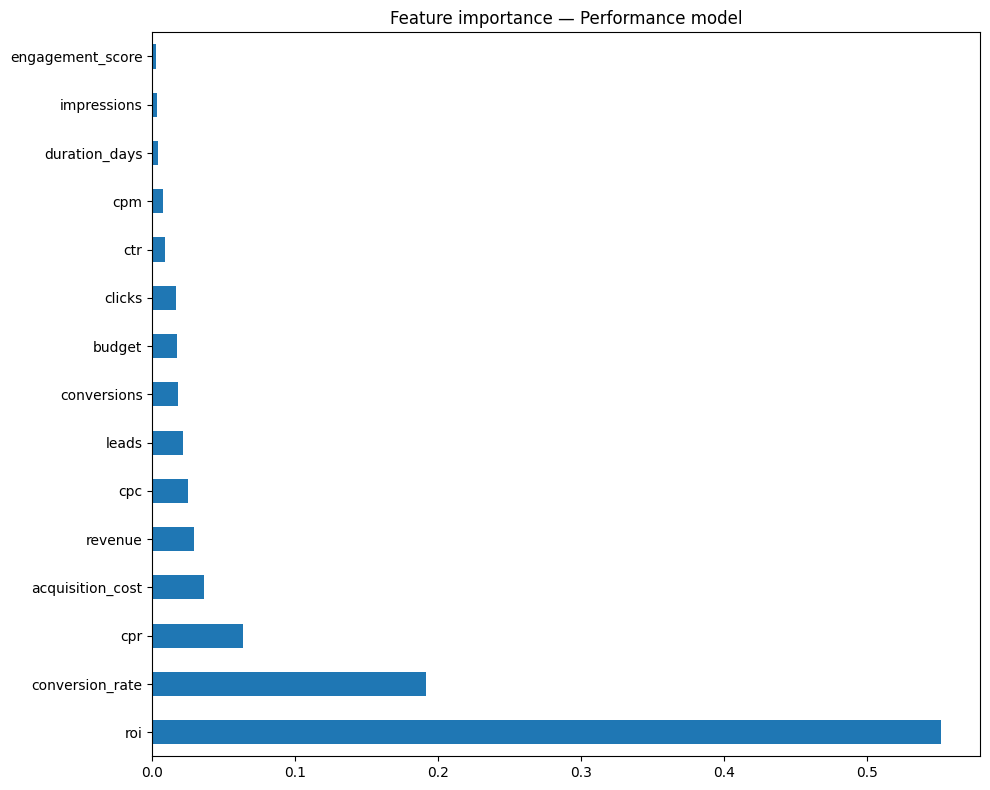

In [19]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    perf_model.feature_importances_,
    index=ALL_FEATURES
).sort_values(ascending=False)

print("Top 10 most important features:")
print(feature_importance.head(10).round(4))

plt.figure(figsize=(10, 8))
feature_importance.head(15).plot(kind="barh")
plt.title("Feature importance — Performance model")
plt.tight_layout()
plt.show()

# The Alert Flag Model

In [20]:
alert_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

alert_model.fit(
    X_train, y_alert_train,
    eval_set=[(X_test, y_alert_test)],
    verbose=100
)

y_alert_pred = alert_model.predict(X_test)

print("\nAlert Flag Model — Evaluation")
print("=" * 50)
print(classification_report(
    y_alert_test, y_alert_pred,
    target_names=["No Alert", "Alert"]
))
print(f"Overall Accuracy: {(y_alert_pred == y_alert_test).mean():.4f}")

# Feature importance
alert_importance = pd.Series(
    alert_model.feature_importances_,
    index=ALL_FEATURES
).sort_values(ascending=False)

print(f"\nTop 10 most important features — alert model:")
print(alert_importance.head(10).round(4))

[0]	validation_0-logloss:0.40575
[100]	validation_0-logloss:0.00721
[200]	validation_0-logloss:0.00422
[299]	validation_0-logloss:0.00391

Alert Flag Model — Evaluation
              precision    recall  f1-score   support

    No Alert       1.00      1.00      1.00    107608
       Alert       1.00      1.00      1.00     23069

    accuracy                           1.00    130677
   macro avg       1.00      1.00      1.00    130677
weighted avg       1.00      1.00      1.00    130677

Overall Accuracy: 0.9983

Top 10 most important features — alert model:
roi                 0.1922
conversions         0.1345
frequency           0.0768
ctr                 0.0655
conversion_rate     0.0637
acquisition_cost    0.0635
revenue             0.0555
engagement_score    0.0517
platform            0.0464
purchases           0.0456
dtype: float32


In [21]:
print("Platform average acquisition cost:")
print(df.groupby("platform")["acquisition_cost"].mean().round(2))

print(f"\nCTR distribution:")
print(f"CTR < 0.02:  {(df['ctr'] < 0.02).sum():,} rows ({(df['ctr'] < 0.02).mean()*100:.1f}%)")
print(f"CTR < 0.05:  {(df['ctr'] < 0.05).sum():,} rows ({(df['ctr'] < 0.05).mean()*100:.1f}%)")
print(f"CTR < 0.10:  {(df['ctr'] < 0.10).sum():,} rows ({(df['ctr'] < 0.10).mean()*100:.1f}%)")

print(f"\nCVR distribution:")
print(f"CVR < 0.02:  {(df['conversion_rate'] < 0.02).sum():,} rows ({(df['conversion_rate'] < 0.02).mean()*100:.1f}%)")
print(f"CVR < 0.03:  {(df['conversion_rate'] < 0.03).sum():,} rows ({(df['conversion_rate'] < 0.03).mean()*100:.1f}%)")
print(f"CVR < 0.05:  {(df['conversion_rate'] < 0.05).sum():,} rows ({(df['conversion_rate'] < 0.05).mean()*100:.1f}%)")

print(f"\nROI distribution:")
print(f"ROI < 0:     {(df['roi'] < 0).sum():,} rows ({(df['roi'] < 0).mean()*100:.1f}%)")
print(f"ROI < 0.5:   {(df['roi'] < 0.5).sum():,} rows ({(df['roi'] < 0.5).mean()*100:.1f}%)")
print(f"ROI < 1.0:   {(df['roi'] < 1.0).sum():,} rows ({(df['roi'] < 1.0).mean()*100:.1f}%)")

Platform average acquisition cost:
platform
Display            0.54
Email            369.83
Facebook        4612.46
Google           365.64
Instagram       4598.62
Other_Social       0.52
Pinterest       7769.74
TikTok          4083.33
Twitter         7774.12
WhatsApp         377.64
YouTube          374.54
Name: acquisition_cost, dtype: float64

CTR distribution:
CTR < 0.02:  7,695 rows (1.2%)
CTR < 0.05:  96,192 rows (14.7%)
CTR < 0.10:  224,360 rows (34.3%)

CVR distribution:
CVR < 0.02:  19,392 rows (3.0%)
CVR < 0.03:  43,777 rows (6.7%)
CVR < 0.05:  91,870 rows (14.1%)

ROI distribution:
ROI < 0:     85,990 rows (13.2%)
ROI < 0.5:   168,190 rows (25.7%)
ROI < 1.0:   243,062 rows (37.2%)


In [22]:
# Compute platform average acquisition cost
platform_avg_cost = df.groupby("platform")["acquisition_cost"].mean()
df["platform_avg_cost"] = df["platform"].map(platform_avg_cost)

# Define alert flag with business logic
df["alert_flag"] = (
    (df["roi"] < 0) |
    (df["conversion_rate"] < 0.03) |
    (df["ctr"] < 0.05) |
    (df["acquisition_cost"] > 3 * df["platform_avg_cost"])
).astype(int)

print("Alert flag distribution:")
print(df["alert_flag"].value_counts())
print(f"\nPercentages:")
print((df["alert_flag"].value_counts() / len(df) * 100).round(1))

print(f"\nSanity check — mean metrics per alert group:")
print(df.groupby("alert_flag")[["roi","ctr","conversion_rate","acquisition_cost"]].mean().round(4))

# Drop helper column
df.drop(columns=["platform_avg_cost"], inplace=True)

Alert flag distribution:
alert_flag
0    470989
1    182392
Name: count, dtype: int64

Percentages:
alert_flag
0    72.1
1    27.9
Name: count, dtype: float64

Sanity check — mean metrics per alert group:
               roi     ctr  conversion_rate  acquisition_cost
alert_flag                                                   
0           3.5982  0.2167           0.1526         4096.5236
1           3.8078  0.1153           0.1424         3197.8620


In [23]:
# Compute platform average acquisition cost
platform_avg_cost = df.groupby("platform")["acquisition_cost"].mean()
df["platform_avg_cost"] = df["platform"].map(platform_avg_cost)

# Refined alert flag
df["alert_flag"] = (
    (df["roi"] < 0) |                                          # losing money
    (df["conversion_rate"] < 0.03) |                           # extremely poor conversion
    (df["ctr"] < 0.05) |                                       # very low engagement
    (                                                          # overspending with poor returns
        (df["acquisition_cost"] > 2 * df["platform_avg_cost"]) &
        (df["roi"] < 1.0)
    )
).astype(int)

print("Alert flag distribution:")
print(df["alert_flag"].value_counts())
print(f"\nPercentages:")
print((df["alert_flag"].value_counts() / len(df) * 100).round(1))

print(f"\nSanity check — mean metrics per alert group:")
print(df.groupby("alert_flag")[["roi","ctr","conversion_rate","acquisition_cost"]].mean().round(4))

df.drop(columns=["platform_avg_cost"], inplace=True)

Alert flag distribution:
alert_flag
0    476816
1    176565
Name: count, dtype: int64

Percentages:
alert_flag
0    73.0
1    27.0
Name: count, dtype: float64

Sanity check — mean metrics per alert group:
               roi     ctr  conversion_rate  acquisition_cost
alert_flag                                                   
0           3.6553  0.2182           0.1518         4262.2612
1           3.6606  0.1080           0.1443         2720.6281


In [26]:
df["alert_flag"] = (
    (df["roi"] < 0) |
    (df["conversion_rate"] < 0.03)
).astype(int)

print("Alert flag distribution:")
print(df["alert_flag"].value_counts())
print(f"\nPercentages:")
print((df["alert_flag"].value_counts() / len(df) * 100).round(1))

print(f"\nSanity check — mean metrics per alert group:")
print(df.groupby("alert_flag")[["roi","ctr","conversion_rate","acquisition_cost"]].mean().round(4))

print(f"\nAlert rate per platform:")
print((df.groupby("platform")["alert_flag"].mean().round(3) * 100).round(1))

Alert flag distribution:
alert_flag
0    530033
1    123348
Name: count, dtype: int64

Percentages:
alert_flag
0    81.1
1    18.9
Name: count, dtype: float64

Sanity check — mean metrics per alert group:
               roi     ctr  conversion_rate  acquisition_cost
alert_flag                                                   
0           3.5701  0.2036           0.1566         4067.4965
1           4.0293  0.1233           0.1203         2892.4235

Alert rate per platform:
platform
Display         95.7
Email           24.2
Facebook        16.3
Google          25.9
Instagram       16.3
Other_Social    92.7
Pinterest       10.7
TikTok          49.9
Twitter         10.5
WhatsApp        23.5
YouTube         24.5
Name: alert_flag, dtype: float64


In [27]:
df["alert_flag"] = (
    (df["roi"] < 0) |
    ((df["roi"] < 1.0) & (df["acquisition_cost"] > df.groupby("platform")["acquisition_cost"].transform("median")))
).astype(int)

print("Alert flag distribution:")
print(df["alert_flag"].value_counts())
print(f"\nPercentages:")
print((df["alert_flag"].value_counts() / len(df) * 100).round(1))

print(f"\nSanity check — mean metrics per alert group:")
print(df.groupby("alert_flag")[["roi","ctr","conversion_rate","acquisition_cost"]].mean().round(4))

print(f"\nAlert rate per platform:")
print((df.groupby("platform")["alert_flag"].mean() * 100).round(1))

Alert flag distribution:
alert_flag
0    479081
1    174300
Name: count, dtype: int64

Percentages:
alert_flag
0    73.3
1    26.7
Name: count, dtype: float64

Sanity check — mean metrics per alert group:
               roi     ctr  conversion_rate  acquisition_cost
alert_flag                                                   
0           4.9839  0.2095           0.1500         3969.0460
1           0.0089  0.1304           0.1491         3506.5261

Alert rate per platform:
platform
Display         92.1
Email           41.9
Facebook        16.3
Google          43.2
Instagram       16.2
Other_Social    87.5
Pinterest       34.9
TikTok          26.5
Twitter          6.1
WhatsApp        41.4
YouTube         42.3
Name: alert_flag, dtype: float64


In [28]:
# ── Rebuild feature matrix with final labels ──────────────────────────
df_model = df[ALL_FEATURES + ["performance_label_enc", "alert_flag"]].copy()

for col in CATEGORICAL_COLS:
    le = label_encoders[col]
    df_model[col] = df_model[col].astype(str).fillna("Unknown")
    df_model[col] = le.transform(df_model[col])

X = df_model[ALL_FEATURES]
y_perf  = df_model["performance_label_enc"]
y_alert = df_model["alert_flag"]

X_train, X_test, y_perf_train, y_perf_test, y_alert_train, y_alert_test = train_test_split(
    X, y_perf, y_alert,
    test_size=0.2,
    random_state=42,
    stratify=y_perf
)

# ── Retrain performance model ─────────────────────────────────────────
perf_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)

perf_model.fit(
    X_train, y_perf_train,
    eval_set=[(X_test, y_perf_test)],
    verbose=100
)

y_perf_pred = perf_model.predict(X_test)

print("\nPerformance Model — Final Evaluation")
print("=" * 50)
print(classification_report(
    y_perf_test, y_perf_pred,
    target_names=["Low", "Medium", "High"]
))
print(f"Overall Accuracy: {(y_perf_pred == y_perf_test).mean():.4f}")

# ── Retrain alert model ───────────────────────────────────────────────
alert_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

alert_model.fit(
    X_train, y_alert_train,
    eval_set=[(X_test, y_alert_test)],
    verbose=100
)

y_alert_pred = alert_model.predict(X_test)

print("\nAlert Flag Model — Final Evaluation")
print("=" * 50)
print(classification_report(
    y_alert_test, y_alert_pred,
    target_names=["No Alert", "Alert"]
))
print(f"Overall Accuracy: {(y_alert_pred == y_alert_test).mean():.4f}")

[0]	validation_0-mlogloss:0.94975
[100]	validation_0-mlogloss:0.00162
[200]	validation_0-mlogloss:0.00138
[299]	validation_0-mlogloss:0.00141

Performance Model — Final Evaluation
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00     53144
      Medium       1.00      1.00      1.00     44948
        High       1.00      1.00      1.00     32585

    accuracy                           1.00    130677
   macro avg       1.00      1.00      1.00    130677
weighted avg       1.00      1.00      1.00    130677

Overall Accuracy: 0.9995
[0]	validation_0-logloss:0.51302
[100]	validation_0-logloss:0.00172
[200]	validation_0-logloss:0.00149
[299]	validation_0-logloss:0.00153

Alert Flag Model — Final Evaluation
              precision    recall  f1-score   support

    No Alert       1.00      1.00      1.00     95648
       Alert       1.00      1.00      1.00     35029

    accuracy                           1.00    130677
   macro avg       1.

# Feature Importance Identification For Both Models

In [29]:
# ── Feature importance comparison ─────────────────────────────────────
perf_importance = pd.Series(
    perf_model.feature_importances_,
    index=ALL_FEATURES
).sort_values(ascending=False)

alert_importance = pd.Series(
    alert_model.feature_importances_,
    index=ALL_FEATURES
).sort_values(ascending=False)

print("Performance model — top 10 features:")
print(perf_importance.head(10).round(4))

print("\nAlert model — top 10 features:")
print(alert_importance.head(10).round(4))

Performance model — top 10 features:
roi                 0.5516
conversion_rate     0.1915
cpr                 0.0633
acquisition_cost    0.0361
revenue             0.0292
cpc                 0.0252
leads               0.0218
conversions         0.0182
budget              0.0171
clicks              0.0164
dtype: float32

Alert model — top 10 features:
roi                 0.4005
clicks              0.1264
ctr                 0.0845
leads               0.0734
reach               0.0575
acquisition_cost    0.0473
frequency           0.0409
budget              0.0393
revenue             0.0382
duration_days       0.0243
dtype: float32


# Saving Everything

In [31]:
# ── Platform averages for imputation (numeric only) ───────────────────
NUMERIC_FEATURES = [f for f in ALL_FEATURES if f not in CATEGORICAL_COLS]

platform_averages = df.groupby("platform")[NUMERIC_FEATURES].mean().to_dict()

# ── Platform median acquisition cost for alert flag ───────────────────
platform_median_cost = df.groupby("platform")["acquisition_cost"].median().to_dict()

# ── Save everything ───────────────────────────────────────────────────
import os
save_dir = "/kaggle/working/model_artifacts"
os.makedirs(save_dir, exist_ok=True)

with open(f"{save_dir}/perf_model.pkl", "wb") as f:
    pickle.dump(perf_model, f)

with open(f"{save_dir}/alert_model.pkl", "wb") as f:
    pickle.dump(alert_model, f)

with open(f"{save_dir}/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

with open(f"{save_dir}/platform_averages.pkl", "wb") as f:
    pickle.dump(platform_averages, f)

with open(f"{save_dir}/platform_median_cost.pkl", "wb") as f:
    pickle.dump(platform_median_cost, f)

with open(f"{save_dir}/feature_list.pkl", "wb") as f:
    pickle.dump(ALL_FEATURES, f)

with open(f"{save_dir}/categorical_cols.pkl", "wb") as f:
    pickle.dump(CATEGORICAL_COLS, f)

print("✓ Saved artifacts:")
for f in os.listdir(save_dir):
    size = os.path.getsize(f"{save_dir}/{f}") / 1024
    print(f"  {f} — {size:.1f} KB")

✓ Saved artifacts:
  label_encoders.pkl — 1.3 KB
  feature_list.pkl — 0.3 KB
  perf_model.pkl — 1877.9 KB
  platform_median_cost.pkl — 0.2 KB
  categorical_cols.pkl — 0.1 KB
  alert_model.pkl — 733.1 KB
  platform_averages.pkl — 3.2 KB
